In [6]:
import pandas as pd
import numpy as np 
sentiment_df = pd.read_csv('data/fear_greed_index.csv')
trader_df = pd.read_csv('data/historical_data.csv')

print("-- SENTIMENT DATASET AUDIT ---")
print(f"Shap: {sentiment_df.shape} (Rows, Columns)")
print("Missing Values:\n", sentiment_df.isnull().sum())

print ("\n--- TRADER DATASET AUDIT ---")
print(f"Shape: {trader_df.shape} (Rows, Columns)")
print("Missing Values:\n", trader_df.isnull().sum())
print(f"Dupicate Rows: {trader_df.duplicated().sum()}")


-- SENTIMENT DATASET AUDIT ---
Shap: (2644, 4) (Rows, Columns)
Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

--- TRADER DATASET AUDIT ---
Shape: (211224, 16) (Rows, Columns)
Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Dupicate Rows: 0


In [10]:


sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.date


if trader_df['Timestamp'].dtype in ['int64', 'float64']:
    trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'], unit='ms')
else:
    trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'])


trader_df['Date'] = trader_df['datetime'].dt.date


trader_df['is_long'] = np.where(trader_df['Side'].str.upper() == 'BUY', 1, 0)
trader_df['is_short'] = np.where(trader_df['Side'].str.upper() == 'SELL', 1, 0)


daily_trader_metrics = trader_df.groupby(['Account', 'Date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Timestamp', 'count'), 
    total_volume=('Size USD', 'sum'),   
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum')
).reset_index()

daily_trader_metrics['long_short_ratio'] = (
    daily_trader_metrics['long_trades'] / (daily_trader_metrics['short_trades'] + 1e-5)
)

print("--- STEP 2 SUCCESSFUL ---")
print(f"Aggregated Daily Trader Rows: {daily_trader_metrics.shape[0]}")

--- STEP 2 SUCCESSFUL ---
Aggregated Daily Trader Rows: 102


In [11]:

final_master_df = pd.merge(daily_trader_metrics, sentiment_df, on='Date', how='inner')

print("--- FINAL MASTER DATASET READY ---")
print(f"Total Combined Rows for Analysis: {final_master_df.shape[0]}")
print(final_master_df[['Account', 'Date', 'daily_pnl', 'classification']].head())

--- FINAL MASTER DATASET READY ---
Total Combined Rows for Analysis: 77
                                      Account        Date      daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -327505.900056   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27   20607.446093   
2  0x271b280974205ca63b716753467d5a371de622ab  2024-10-27    1793.160215   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  2024-10-27  121880.386016   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  2024-10-27   52215.729448   

  classification  
0          Greed  
1          Greed  
2          Greed  
3          Greed  
4          Greed  


In [19]:
final_master_df['is_profitable_day'] = np.where(final_master_df['daily_pnl']>0, 1, 0)
sentiment_analysis = final_master_df.groupby('classification').agg(
    total_days_tracked=('Date','count'),
    average_daily_pnl=('daily_pnl','mean'),
    median_daily_pnl=('daily_pnl','median'),
    win_rate_percentage=('is_profitable_day', 'mean'),
    avg_trades_per_day=('trade_count', 'mean'),
    avg_volume_used_per_day=('total_volume', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

sentiment_analysis['win_rate_percentage'] = (sentiment_analysis['win_rate_percentage'] * 100).round(2)

print("--- SENTIMENT ANALYSIS BREADOWN ---")
print(sentiment_analysis.to_string(index=False))




--- SENTIMENT ANALYSIS BREADOWN ---
classification  total_days_tracked  average_daily_pnl  median_daily_pnl  win_rate_percentage  avg_trades_per_day  avg_volume_used_per_day  avg_long_short_ratio
 Extreme Greed                   5       35393.098355          0.000000                40.00          1392.40000             7.881354e+06          1.760001e+06
          Fear                  32      209372.662205      81389.682516                93.75          4183.46875             2.200495e+07          9.681304e-01
         Greed                  32       99675.516730      35988.376437                84.38          1134.03125             3.609490e+06          7.593761e+05
       Neutral                   8       19842.797260         -0.418640                50.00           892.62500             2.730404e+06          1.243286e+00


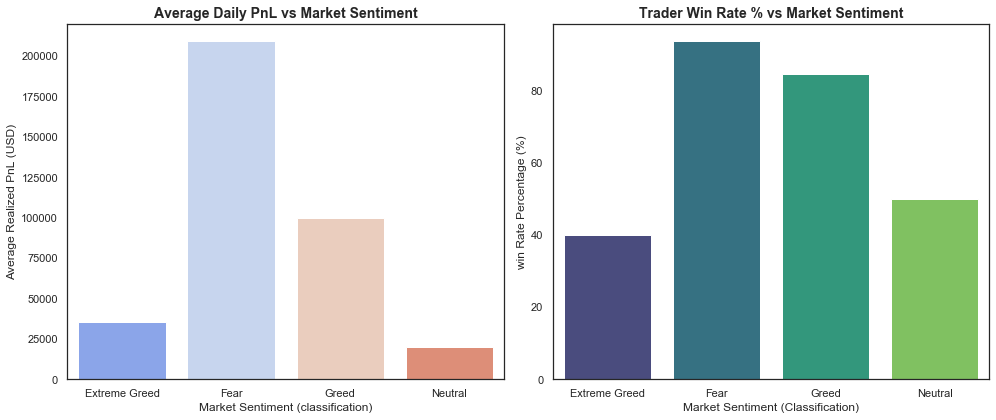

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set(style="darkgrid")
fig, axes = plt.subplots(1,2, figsize=(14, 6))
sns.barplot(
    data=sentiment_analysis,
    x='classification',
    y='average_daily_pnl',
    ax=axes[0],
    palette='coolwarm'

)
axes[0].set_title('Average Daily PnL vs Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment (classification)', fontsize=12)
axes[0].set_ylabel('Average Realized PnL (USD)', fontsize=12)

sns.barplot(
    data=sentiment_analysis,
    x='classification',
    y='win_rate_percentage',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Trader Win Rate % vs Market Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiment (Classification)', fontsize=12)
axes[1].set_ylabel('win Rate Percentage (%)', fontsize=12)

plt.tight_layout()
plt.show()
